## Exploring Cross Infection between two variants
**Author:** Karen Guzman

**Description:** Exploring a two-variant SIR model with cross-infection. This is a cycle that allows individuals to become with variants multiple times. $R_1$ contains individuals that have recovered from variant 1 and that are immediately susceptible to variant 2. Each variant can be immediately contracted following the recovery of the other variant, as there is no cross immunity. This is a 5-compartment model containing groups $S, I_1, I_2, R_1, R_2$.


**Date:** 6/27/2026

In [19]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../models')
#imports
import numpy as np
import matplotlib.pyplot as plt
import cross_infection_2 as ci

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Scenarios
**Scenario 1:** Emergence of variant 2 long after variant 1

R0 of variant 1: 1.27
R0 of variant 2: 7.08
R0 of variant 2 at emergence: 7.08
Prevalence Peak V1: 52.8 at t=10.5
Prevalence Peak V2: 582.3 at t=162.3

Never infected: 0
Infected by variant 1: 1
Infected by variant 2: 998
Total: 1000
(Still infected at end of run: 0.2 - should extend t_total)
Figure saved to figures/cross_inf_2_scenario_1.png


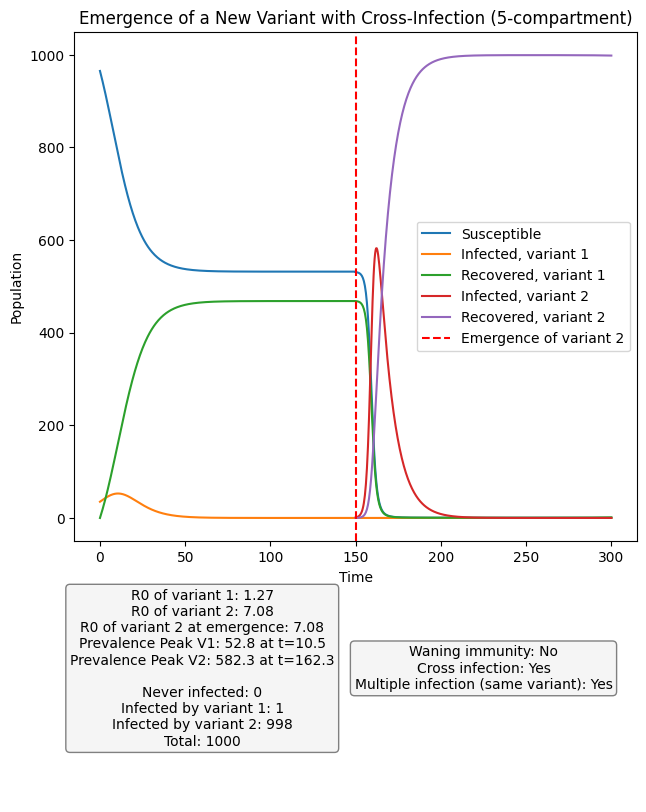

In [20]:
#where variant 2 emerges and takes over
params = [0.42, 0.85, 0.33, 0.12, 1, 1] #beta1, beta2, gamma1, gamma2, eta12, eta21
y0 = [965, 35, 0, 0, 0] # 965 susceptible, 35 infected with strain 1
t, y = ci.simulate_cross_infection(params, y0, t_emerge=150)

ci.plot_cross_infection(t, y, params, filename="cross_inf_2_scenario_1.png")

This model takes the same parameters as the 9-compartment model. Although they have the same results, they display it in different ways. This is because the number of compartments was reduced, so there is no way to keep track of the history of infections for a single individual. Therefore, we trade off infection tracking for a simpler, more interpretable model.

**Scenario 2:** Variant 1 and 2 circulating at the same time

R0 of variant 1: 1.27
R0 of variant 2: 7.08
R0 of variant 2 at emergence: 6.71
Prevalence Peak V1: 52.7 at t=10.4
Prevalence Peak V2: 563.2 at t=20.9

Never infected: 0
Infected by variant 1: 144
Infected by variant 2: 784
Total: 1000
(Still infected at end of run: 72.3 - should extend t_total)
Figure saved to figures/cross_inf_2_scenario_2.png


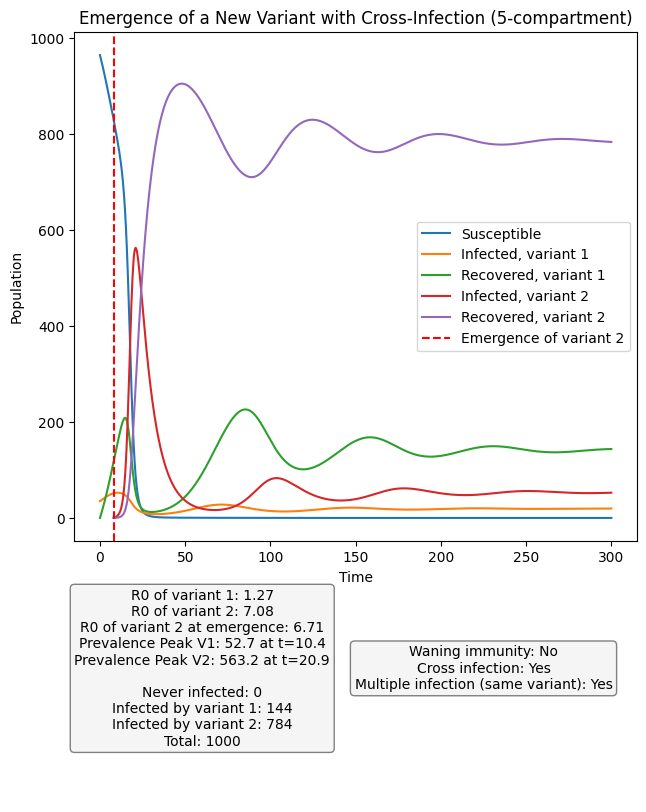

In [21]:
#same params as scenario 1, changing emergence time to 8 days
params = [0.42, 0.85, 0.33, 0.12, 1, 1] #beta1, beta2, gamma1, gamma2
y0 = [965, 35, 0, 0, 0] # 965 susceptible, 35 infected with strain 1, 0 infected with strain 2, 0 recovered from strain 1, 0 recovered from strain 2
t, y = ci.simulate_cross_infection(params, y0, t_emerge=8)

ci.plot_cross_infection(t, y, params, filename="cross_inf_2_scenario_2.png")

This model shows the same peaks and $R_0$ of the epidemic. In this plot, you can see how the epidemic curves change to multiple oscillating waves. 